<a href="https://colab.research.google.com/github/Ritupriya176/Brain-Tumor-Detection-and-Classification/blob/main/SDP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports Python Libraries**

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from PIL import Image as PILImage
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Loading Datasets**

In [ ]:
train_dir = '/content/drive/MyDrive/MRI_Images/Training'
test_dir = '/content/drive/MyDrive/MRI_Images/Testing'
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# **Data Visualization**

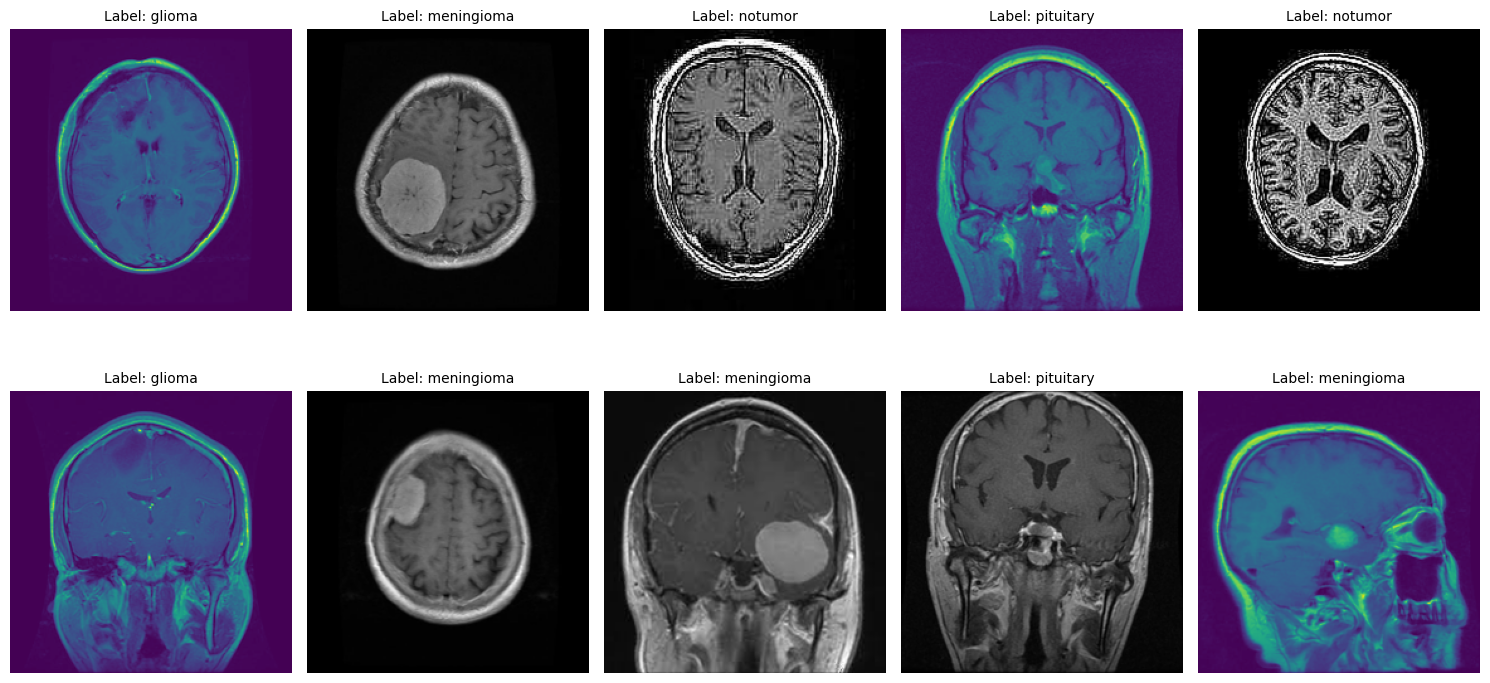

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

# **Image Preprocessing**

In [ ]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

# **VGG 16**

In [ ]:
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps
)



Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1439s 5s/step - loss: 0.4673 - sparse_categorical_accuracy: 0.8211
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1418s 5s/step - loss: 0.2400 - sparse_categorical_accuracy: 0.9139
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1416s 5s/step - loss: 0.1651 - sparse_categorical_accuracy: 0.9382
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1422s 5s/step - loss: 0.1141 - sparse_categorical_accuracy: 0.9587
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1418s 5s/step - loss: 0.1049 - sparse_categorical_accuracy: 0.9587


# **Architecture**

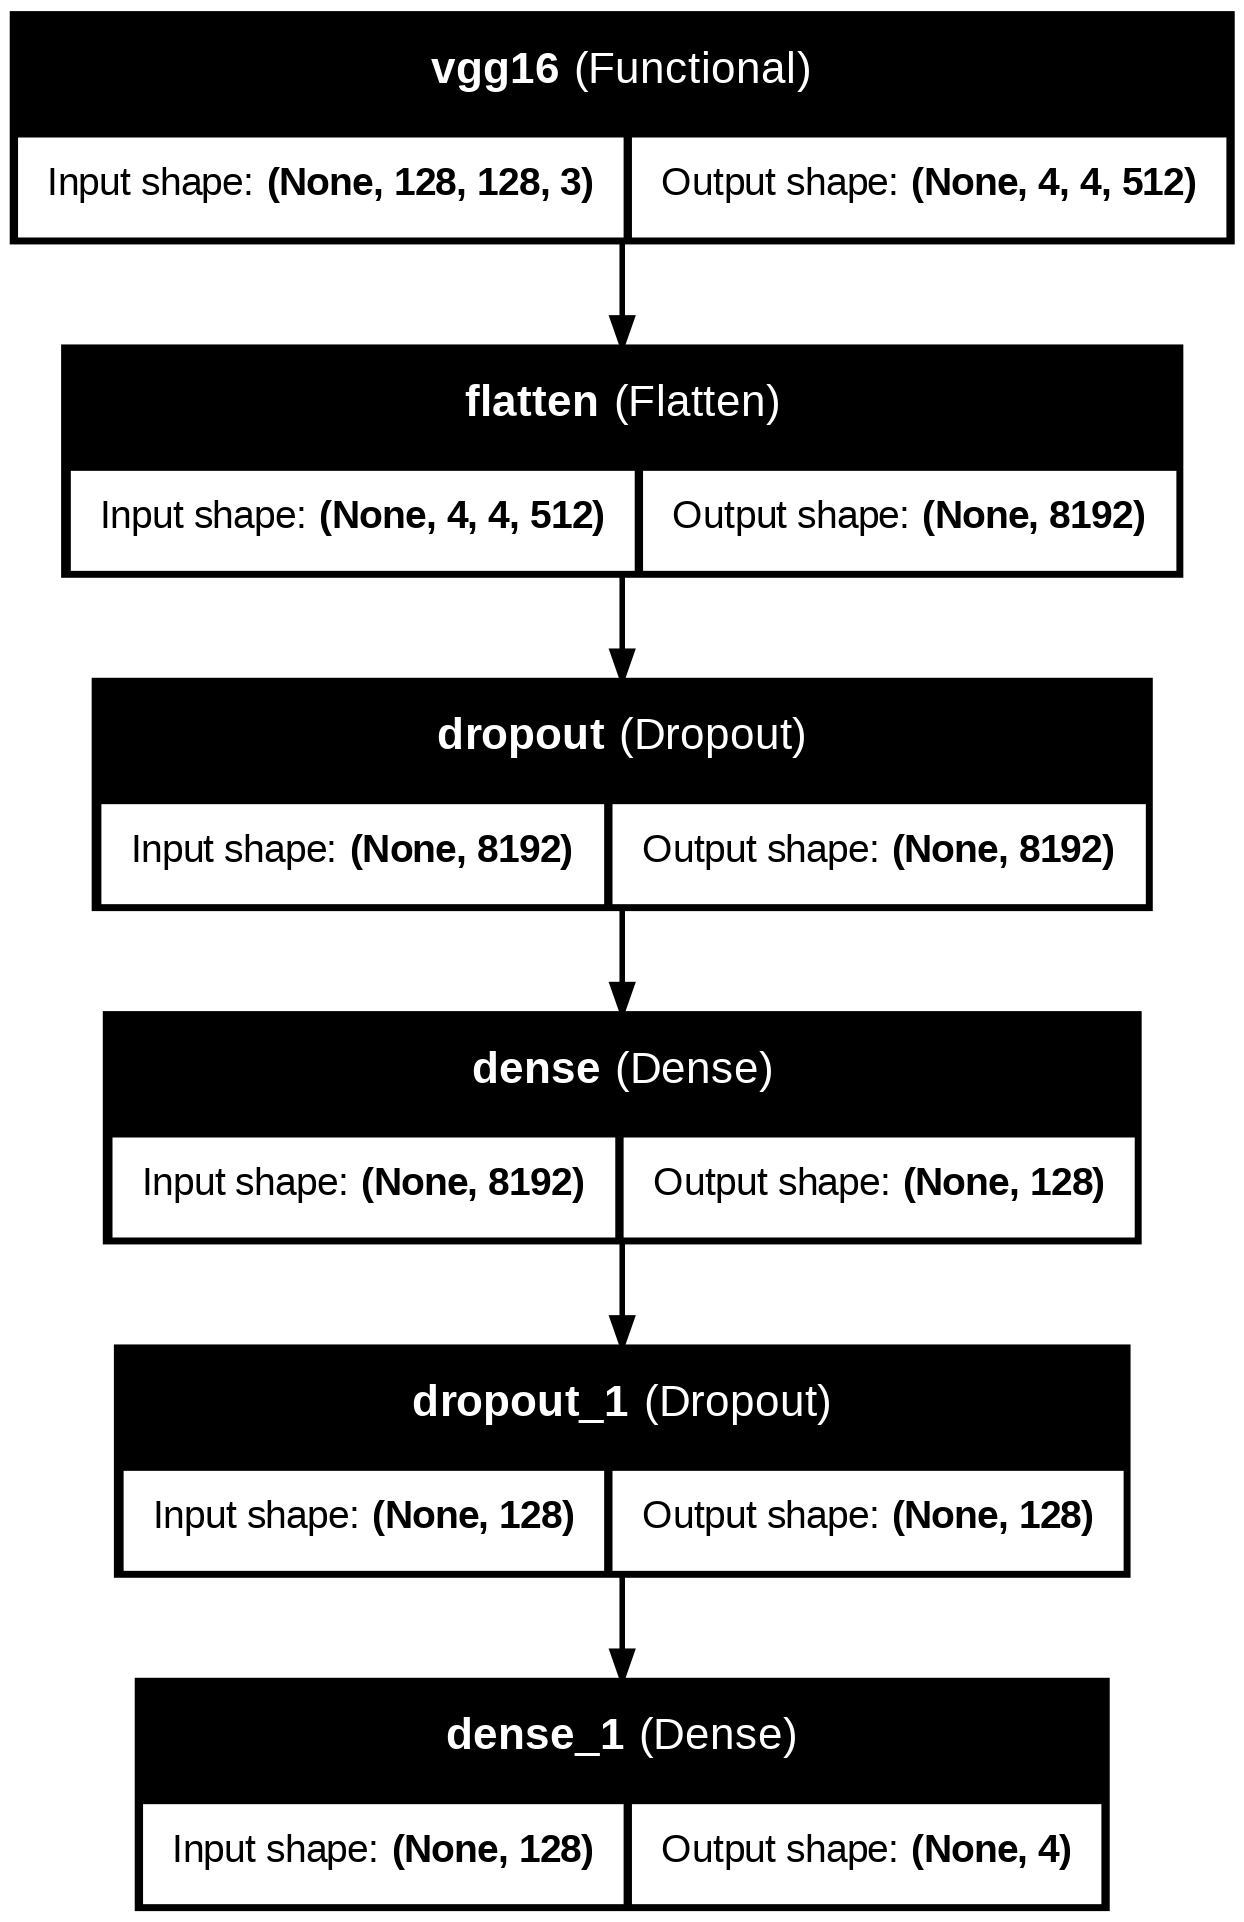

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

plot_model(model,
           to_file='vgg16_model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           dpi=200)

display(Image(filename='vgg16_model_architecture.png'))

# **Classification Report**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━━━━━━ 233s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       355
           1       0.97      0.99      0.98       351
           2       0.98      0.91      0.94       324
           3       0.98      1.00      0.99       400

    accuracy                           0.96      1430
   macro avg       0.96      0.96      0.96      1430
weighted avg       0.96      0.96      0.96      1430



# **Confusion Matrix**

Confusion Matrix:
[[334   6  10   5]
 [  2 348   1   0]
 [ 25   2 295   2]
 [  0   0   0 400]]


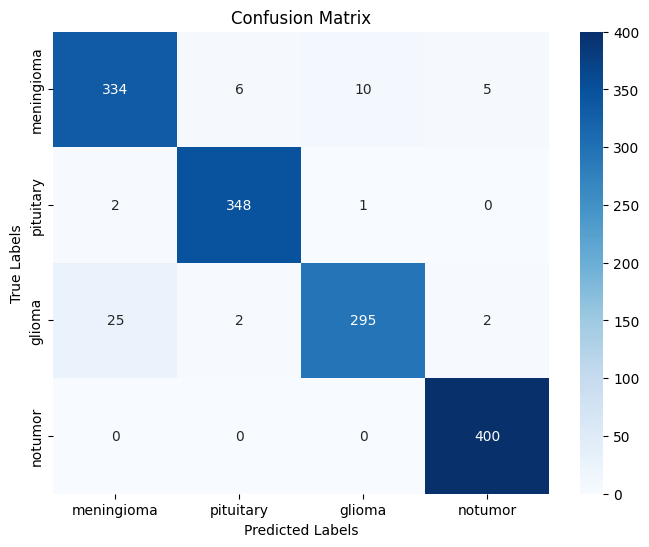

In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# **Ensemble(VGG 16 + Xception)**

In [ ]:
from tensorflow.keras.applications import VGG16, Xception
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMAGE_SIZE = 128
num_classes = len(os.listdir(train_dir))

input_layer = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
for layer in vgg_model.layers[:-4]:
    layer.trainable = False
vgg_out = vgg_model(input_layer)
vgg_features = GlobalAveragePooling2D()(vgg_out)

xception_model = Xception(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
for layer in xception_model.layers[:-10]:
    layer.trainable = False
xception_out = xception_model(input_layer)
xception_features = GlobalAveragePooling2D()(xception_out)

merged = Concatenate()([vgg_features, xception_features])

x = Dropout(0.5)(merged)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

ensemble_model = Model(inputs=input_layer, outputs=output)

ensemble_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['sparse_categorical_accuracy'])
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = ensemble_model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1707s 6s/step - loss: 0.4770 - sparse_categorical_accuracy: 0.8193
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1689s 6s/step - loss: 0.1973 - sparse_categorical_accuracy: 0.9290
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1701s 6s/step - loss: 0.1101 - sparse_categorical_accuracy: 0.9606
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1693s 6s/step - loss: 0.0584 - sparse_categorical_accuracy: 0.9805
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1683s 6s/step - loss: 0.0357 - sparse_categorical_accuracy: 0.9881


# **Architecture**

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

plot_model(ensemble_model,
           to_file='hybrid_ensemble_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,
           dpi=200)

display(Image(filename='hybrid_ensemble_architecture.png'))

# **Classification Report**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = ensemble_model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━━━━━━ 233s 6s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       355
           1       0.99      0.98      0.98       351
           2       0.95      0.97      0.96       324
           3       0.98      0.98      0.98       400

    accuracy                           0.98      1430
   macro avg       0.97      0.98      0.97      1430
weighted avg       0.97      0.98      0.97      1430



# **Confusion Matrix**

Confusion Matrix:
[[344   4   4   3]
 [  2 344   3   2]
 [  4   1 314   5]
 [  1   2   5 392]]


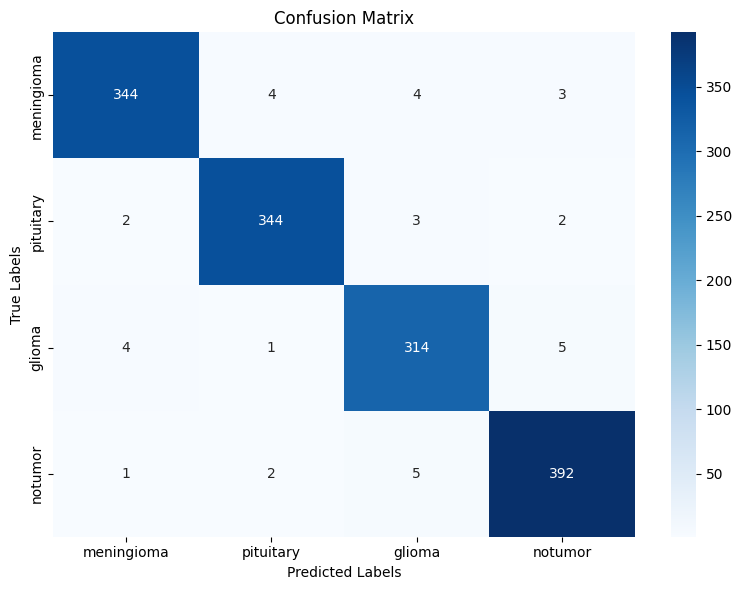

In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# **Conclusion**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

vgg_preds_raw = model.predict(test_images)
vgg_preds = np.argmax(vgg_preds_raw, axis=1)

ens_preds_raw = ensemble_model.predict(test_images)
ens_preds = np.argmax(ens_preds_raw, axis=1)

target_names = os.listdir(train_dir)
vgg_report = classification_report(test_labels_encoded, vgg_preds, target_names=target_names, output_dict=True)
ens_report = classification_report(test_labels_encoded, ens_preds, target_names=target_names, output_dict=True)

comparison_data = {
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'VGG16 (Baseline)': [
        vgg_report['accuracy'],
        vgg_report['macro avg']['precision'],
        vgg_report['macro avg']['recall'],
        vgg_report['macro avg']['f1-score']
    ],
    'Hybrid Ensemble': [
        ens_report['accuracy'],
        ens_report['macro avg']['precision'],
        ens_report['macro avg']['recall'],
        ens_report['macro avg']['f1-score']
    ]
}

df_compare = pd.DataFrame(comparison_data)
print("--- Model Comparison Table ---")
print(df_compare)

41/41 ━━━━━━━━━━━━━━━━━━━━━━━━━ 233s 6s/step
41/41 ━━━━━━━━━━━━━━━━━━━━━━━━━ 334s 8s/step
--- Model Comparison Table ---
           Metric  VGG16 (Baseline)  Hybrid Ensemble
         Accuracy            0.9643           0.9821
  Macro Precision            0.9610           0.9815
     Macro Recall            0.9672           0.9821
   Macro F1-Score            0.9598           0.9818



In [ ]:
save_path = '/content/drive/MyDrive/My_MRI_Models/final_model.keras'

model.save(save_path)

print("Model saved at:", save_path)

Model saved at: /content/drive/MyDrive/My_MRI_Models/final_model.keras


In [ ]:
print(model.output_shape)

(None, 4)


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/My_MRI_Models/final_model.keras')

# **MRI Tumor Detection System**

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_labels = ['meningioma','pituitary', 'glioma', 'notumor']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step


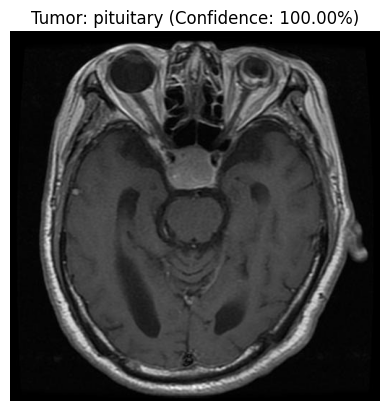

In [ ]:
image_path = '/content/drive/MyDrive/MRI_Images/Testing/pituitary/Te-pi_0054.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


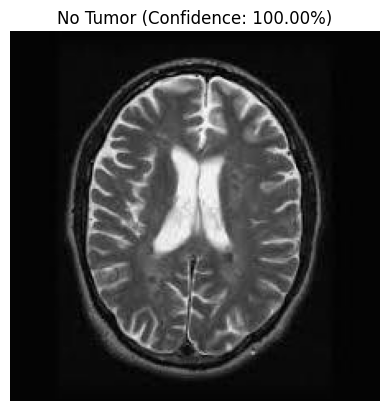

In [ ]:
image_path = '/content/drive/MyDrive/MRI_Images/Testing/notumor/Te-no_0383.jpg'
detect_and_display(image_path, model)